# Algorithm 2

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator

### The Diffusion matrix 
The diffusion matrix:
$$D_x = 2|\phi_x\rangle\langle\phi_x| - I$$
Repersents that the wave function of the particle at node x is diffused across all its neighbours, where the neighbours are repersented using the star state i.e. $|\phi_x\rangle$. Basically a quantum random walk where when choosing between multiple neighbours the wave function "diffuses" to all the neighbours according to the star state.

The star state:
$$|\phi_x\rangle = \sum_{y \sim x} \sqrt{\frac{w_{xy}}{d_x}} |y\rangle$$
Is basically just a weighted superpositions of the neighbours (y) from the point of view of node x where the amplitude is the square root of the normalized conductance (note that conductance is basically the inverse of the cost or weight of a node)

In [2]:
def get_diffusion_matrix(adj_list, node_idx, num_qubits):
    """Creates the reflection matrix D_x = 2|phi_x><phi_x| - I"""
    N = 2**num_qubits
    phi_x = np.zeros(N)
    neighbors = adj_list[node_idx]
    
    total_weight = sum(w for _, w in neighbors)
    for y, w in neighbors:
        phi_x[y] = np.sqrt(w / total_weight)
        
    projection = np.outer(phi_x, phi_x)
    return 2 * projection - np.eye(N)

### Anti Symmertic Star State (i.e. Initial state)

5 amp current flowing from s to y is the same as -5 flowing from y to s therefore we need the anti-symmetric state (normalized by 1/sqrt(2))

In [3]:
def get_initial_state_vector(adj_list, s, node_qubits):
    """
    Creates the exact state vector for the antisymmetrized star state |phi_s^->.
    Corrected for Qiskit's Little-Endian tensor product ordering.
    """
    N = 2**node_qubits
    vec = np.zeros(N * N, dtype=complex) 
    
    neighbors = adj_list[s]
    total_weight = sum(w for _, w in neighbors)
    
    for y, w in neighbors:
        amp = np.sqrt(w / total_weight) / np.sqrt(2)
        # Corrected Indexing: v * N + u
        vec[y * N + s] += amp  # Represents state |u=s, v=y>
        vec[s * N + y] -= amp  # Represents state |u=y, v=s>
        
    return vec

In [4]:
def build_U_gate(adj_list, s, t, node_qubits):
    """Constructs the Walk Operator U = SWAP * (Direct Sum of D_x)"""

    #The register |u,v> repersents the state of the walk, where |u> is the current node and |v> is the next node.
    n_nodes = len(adj_list)
    reg_u = QuantumRegister(node_qubits, 'u')
    reg_v = QuantumRegister(node_qubits, 'v')
    qc_u = QuantumCircuit(reg_u, reg_v, name='U_walk')

    # Apply Conditional Reflections D_x
    for x in range(n_nodes):
        if x == s or x == t:
            # -I boundary conditions for source/sink
            D_x_mat = -np.eye(2**node_qubits)
        else:
            # Internal node reflections
            D_x_mat = get_diffusion_matrix(adj_list, x, node_qubits)
            
        D_x_gate = UnitaryGate(D_x_mat, label=f'D_{x}')
        ctrl_state_str = format(x, f'0{node_qubits}b')
        c_D_x = D_x_gate.control(num_ctrl_qubits=node_qubits, ctrl_state=ctrl_state_str) #a multi control gate that applies D_x only when reg_u is in state |x>
        qc_u.append(c_D_x, [*reg_u, *reg_v])

    # Apply SWAP basically swaps the registers |u> and |v>, which corresponds to moving from the current node to the next node in the walk.
    for i in range(node_qubits):
        qc_u.swap(reg_u[i], reg_v[i])

    return qc_u.to_gate()

In [5]:
from qiskit.circuit.library import PhaseEstimation

def build_flow_circuit(adj_list, s, t, precision):
    """Assembles the QPE circuit using Qiskit's built-in PhaseEstimation."""
    n_nodes = len(adj_list)
    node_qubits = int(np.ceil(np.log2(n_nodes))) #how many qubits are required

    # Registers
    ctrl = QuantumRegister(precision, 'phase')
    reg_u = QuantumRegister(node_qubits, 'u')
    reg_v = QuantumRegister(node_qubits, 'v')
    
    c_phase = ClassicalRegister(precision, 'c_phase')
    c_u = ClassicalRegister(node_qubits, 'c_u')
    c_v = ClassicalRegister(node_qubits, 'c_v')
    
    qc = QuantumCircuit(ctrl, reg_u, reg_v, c_phase, c_u, c_v)

    # Initialize Edge Registers to the antisymmetrized star state
    init_vec = get_initial_state_vector(adj_list, s, node_qubits)
    qc.initialize(init_vec, [*reg_u, *reg_v])

    # Construct the Walk Operator U
    U_gate = build_U_gate(adj_list, s, t, node_qubits)
    
    # 3. Apply the built-in Phase Estimation
    # This automatically builds the Hadamards, the CU^(2^i) sequence, and the IQFT
    qpe_block = PhaseEstimation(precision, U_gate)
    
    # Append it to the circuit. 
    # QPE expects the evaluation (clock) qubits first, then the state qubits.
    qc.append(qpe_block, [*ctrl, *reg_u, *reg_v])

    # 4. Measure all registers
    qc.measure(ctrl, c_phase)
    qc.measure(reg_u, c_u)
    qc.measure(reg_v, c_v)

    return qc, node_qubits

In [6]:
def extract_quantum_flow(graph, source, sink, precision_qubits, shots=2048):
    """
    Executes the quantum flow state simulation and extracts edge probabilities.
    Returns a dictionary mapping edges to their measured flow probabilities.
    """
    print(f"Building circuit for {source} -> {sink}...")
    qc, node_q = build_flow_circuit(graph, source, sink, precision_qubits)
    
    backend = AerSimulator()
    compiled_circuit = transpile(qc, backend)
    job = backend.run(compiled_circuit, shots=shots)
    counts = job.result().get_counts()

    flow_edges = {}
    target_phase = '0' * precision_qubits
    total_successes = 0

    # Parse Qiskit's bitstring format: "c_v c_u c_phase"
    for bitstring, count in counts.items():
        v_str, u_str, phase_str = bitstring.split(' ')
        
        # Post-select for Phase = 0
        if phase_str == target_phase:
            total_successes += count
            u_node = int(u_str, 2)
            v_node = int(v_str, 2)
            
            # Sort to aggregate undirected edges
            edge = tuple(sorted((u_node, v_node)))
            flow_edges[edge] = flow_edges.get(edge, 0) + count

    # Calculate final probability distribution
    edge_probabilities = {}
    if total_successes > 0:
        print(f"\n--- RESULTS ({source}->{sink}) ---")
        print(f"Total Successful Projections (Phase = {target_phase}): {total_successes}")
        print("Probability Distribution of Edges in Flow State:")
        
        for edge, count in flow_edges.items():
            prob = count / total_successes
            edge_probabilities[edge] = prob
            print(f"  Edge {edge}: {prob:.4f}")
    else:
        print("\n--- RESULTS ---")
        print("No successful phase measurements. Try increasing precision or shots.")
        
    return edge_probabilities

Building circuit for 0 -> 2...

--- RESULTS (0->2) ---
Total Successful Projections (Phase = 000): 1059
Probability Distribution of Edges in Flow State:
  Edge (1, 2): 0.5080
  Edge (0, 1): 0.4920


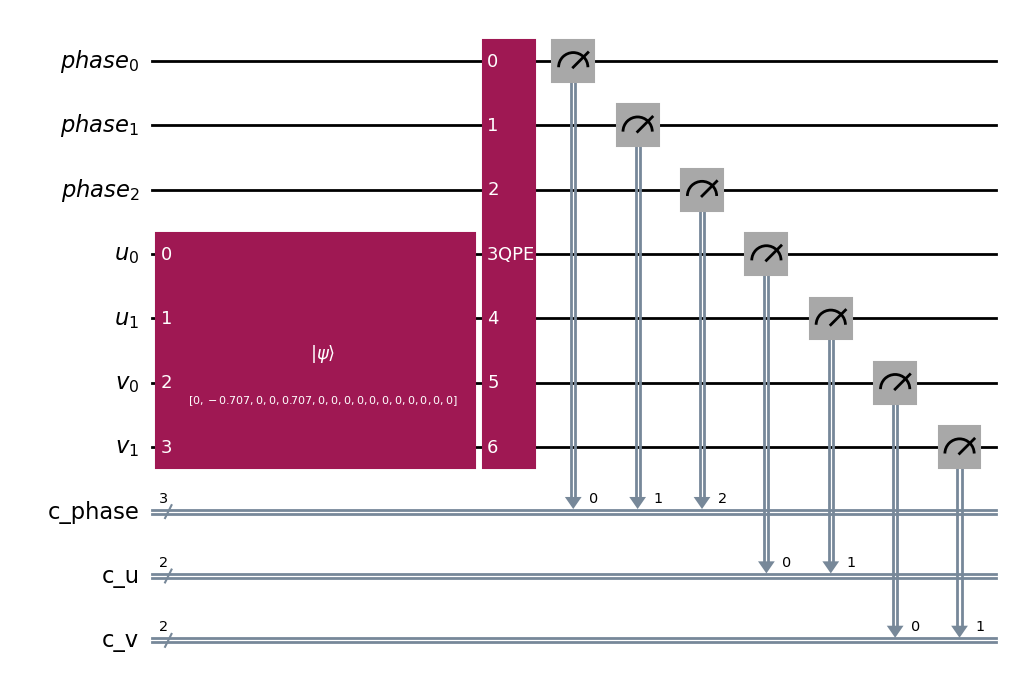

In [7]:
graph = {
    0: [(1, 1.0)],
    1: [(0, 1.0), (2, 1.0)],
    2: [(1, 1.0)]
}

extract_quantum_flow(graph, source=0, sink=2, precision_qubits=3)

qc, node = build_flow_circuit(graph, 0, 2, 3)
qc.draw('mpl')

In [ ]:
graph = {
    0: [(1,2), (4,5)],
    1: [(0,2), (2,10/3), (3,5/2), (4,10/7)],
    2: [(1,10/3), (3,10/8), (4,2)],
    3: [(1,5/2), (2,10/8), (4,5/3)],
    4: [(0,5), (1,10/7), (2,2), (3,5/3)]
}

extract_quantum_flow(graph, source=0, sink=3, precision_qubits=5) #going from 3 to 5 precision qubits increased run time from approx 3 mins to approx 9 mins


Building circuit for 0 -> 3...


KeyboardInterrupt: 

### Effective resistance:

The effective resistance is given by:

$$R_{eff} = L_{pinv}[s,s] + L_{pinv}[t,t] - 2L_{pinv}[s,t]$$

Where $L_{pinv}$ repersents the pseudoinverse the of the graph laplacian

In [8]:
def get_effective_resistance(adj_list, s, t):
    """Calculates R_eff(s, t) using the Laplacian matrix."""
    n = len(adj_list)
    L = np.zeros((n, n))
    
    # Build the Laplacian Matrix: L = Degree - Adjacency
    # We assume the weights 'w' represent conductance (1/Resistance)
    for u in adj_list:
        for v, w in adj_list[u]:
            L[u, u] += w        # Add to degree (diagonal)
            L[u, v] -= w        # Subtract from adjacency (off-diagonal)
            
    # Use the Moore-Penrose pseudoinverse to solve the system
    L_pinv = np.linalg.pinv(L)
    
    # R_eff(s,t) = L^+_ss + L^+_tt - 2 * L^+_st
    r_eff = L_pinv[s, s] + L_pinv[t, t] - 2 * L_pinv[s, t]
    
    # If the graph is disconnected, pinv might yield near-zero or garbage. 
    # A true disconnect approaches infinite resistance.
    if np.isclose(r_eff, 0.0) and s != t:
        return float('inf')
        
    return abs(r_eff)

In [9]:
def remove_edge(adj_list, u, v):
    """Returns a new graph with the edge (u, v) removed."""
    new_adj = {node: list(edges) for node, edges in adj_list.items()}
    new_adj[u] = [(n, w) for n, w in new_adj[u] if n != v]
    new_adj[v] = [(n, w) for n, w in new_adj[v] if n != u]
    return new_adj

def run_quantum_subroutine(adj_list, s, t, precision=3, shots=2048):
    """
    Wraps the Qiskit code we built earlier.
    Returns a sorted list of candidate edges based on flow probabilities.
    """
    print(f"  [Quantum] Sifting flow state for {s} -> {t}...")
    qc, node_q = build_flow_circuit(adj_list, s, t, precision)
    
    backend = AerSimulator()
    compiled = transpile(qc, backend)
    counts = backend.run(compiled, shots=shots).result().get_counts()
    
    target_phase = '0' * precision
    flow_edges = {}
    
    for bitstring, count in counts.items():
        v_str, u_str, phase_str = bitstring.split(' ')
        if phase_str == target_phase:
            u_node, v_node = int(u_str, 2), int(v_str, 2)
            edge = tuple(sorted((u_node, v_node)))
            flow_edges[edge] = flow_edges.get(edge, 0) + count
            
    # Return edges sorted by probability (highest first)
    return sorted(flow_edges.keys(), key=lambda e: flow_edges[e], reverse=True)

### Piddock Algorithm 2:

1. Quantum Sampling: Analogous to how the current is sent to flow from the source to the destination and the edge carrying the highest current (i.e. lowest conductance) is the top canditate.
2. Calculates the effective resistance of the top 3 candidates from the previous step and then finds e* i.e. the edge with the most conductance and attached to e* are u,v where s is closer to u than v.
3. Ensures that u is encountered before v in the route else swaps them.
4. Recursive call from s-->u and then v-->t for the same till the base case isnt reached.

In [10]:
def algorithm_2(adj_list, s, t, precision=3):
    """
    The main recursive Divide and Conquer algorithm.
    """
    # Base Case 1: Reached the target
    if s == t:
        return []
        
    # Base Case 2: Only one direct edge connects them (No other paths)
    r_current = get_effective_resistance(adj_list, s, t)
    test_graph = remove_edge(adj_list, s, t)
    if get_effective_resistance(test_graph, s, t) == float('inf'):
        return [(s, t)]

    # 1. Quantum Sampling: Get candidate edges
    candidates = run_quantum_subroutine(adj_list, s, t, precision)
    
    if not candidates:
        print(f"  [Warning] Quantum walk failed to find edges for {s}->{t}. Falling back.")
        return [(s, t)] # Fallback if precision/shots fail

    # 2. Classical Validation: Find the resistance spike
    max_resistance = -1
    e_star = None
    
    for u, v in candidates[:3]: # Only check the top few candidates to save time
        temp_graph = remove_edge(adj_list, u, v)
        r_temp = get_effective_resistance(temp_graph, s, t)
        
        if r_temp > max_resistance:
            max_resistance = r_temp
            e_star = (u, v)

    print(f"  [Classical] Validated e* = {e_star} (Spike: {r_current:.3f} -> {max_resistance:.3f})")
    
    # 3. Orient the edge: Ensure u is closer to s than v
    u, v = e_star
    if get_effective_resistance(adj_list, s, u) > get_effective_resistance(adj_list, s, v):
        u, v = v, u # Swap them

    # 4. Divide and Conquer: Split the problem
    print(f"  [Split] Dividing at {u}-{v}. Sub-problems: ({s}->{u}) and ({v}->{t})")
    left_path = algorithm_2(adj_list, s, u, precision)
    right_path = algorithm_2(adj_list, v, t, precision)

    # Recombine the path
    return left_path + [(u, v)] + right_path

In [ ]:
diamond_graph = {
    0: [(1, 1.0), (2, 0.1)],
    1: [(0, 1.0), (3, 1.0)],
    2: [(0, 0.1), (3, 0.1)],
    3: [(1, 1.0), (2, 0.1)]
}

print("Starting Algorithm 2...")
shortest_path = algorithm_2(diamond_graph, s=0, t=3, precision=3)

print("\nFINAL RESULT:")
print("Optimal Path Edges:", shortest_path)

Starting Algorithm 2...
  [Quantum] Sifting flow state for 0 -> 3...
  [Classical] Validated e* = (1, 3) (Spike: 1.818 -> 20.000)
  [Split] Dividing at 1-3. Sub-problems: (0->1) and (3->3)
  [Quantum] Sifting flow state for 0 -> 1...
  [Classical] Validated e* = (0, 1) (Spike: 0.955 -> 21.000)
  [Split] Dividing at 0-1. Sub-problems: (0->0) and (1->1)

FINAL RESULT:
Optimal Path Edges: [(0, 1), (1, 3)]


In [ ]:
shortest_path = algorithm_2(graph, s=0, t=3, precision=5)
print("Optimal Path Edges:", shortest_path) #about 10 mins per edge

  [Quantum] Sifting flow state for 0 -> 3...
  [Classical] Validated e* = (0, 4) (Spike: 0.356 -> 0.736)
  [Split] Dividing at 0-4. Sub-problems: (0->0) and (4->3)
  [Quantum] Sifting flow state for 4 -> 3...
  [Classical] Validated e* = (3, 4) (Spike: 0.265 -> 0.474)
  [Split] Dividing at 4-3. Sub-problems: (4->4) and (3->3)
Optimal Path Edges: [(0, 4), (4, 3)]


In [ ]:
def generate_sequence_forwarding_table(adj_list, sequence_nodes):
    """
    Generates a SeQUeNCe forwarding table. 
    Translates SeQUeNCe string names ("r1") to your graph's integer keys (0) 
    before running the math, then translates back to strings for the output.
    """
    # Create simple mappings: 'r1' -> 0, 'r2' -> 1, etc.
    str_to_int = {name: idx for idx, name in enumerate(sequence_nodes)}
    int_to_str = {idx: name for idx, name in enumerate(sequence_nodes)}
    
    # Initialize empty routing lists for every requested node
    forwarding_rules = {node: [] for node in sequence_nodes}
    
    for src in sequence_nodes:
        for dst in sequence_nodes:
            if src == dst:
                continue
                
            print(f"--- Computing route for {src} -> {dst} ---")
            
            # 1. Translate string source/target to integers for your algorithm
            src_idx = str_to_int[src]
            dst_idx = str_to_int[dst]
            
            # 2. Run the quantum recursive algorithm (math happens safely here)
            # It returns integer tuples, e.g., [(0, 1), (1, 3)]
            optimal_path_int = algorithm_2(adj_list, src_idx, dst_idx)
            
            # 3. Extract the "Next Hop" and translate back to strings for SeQUeNCe
            if optimal_path_int:
                first_edge = optimal_path_int[0]  # e.g., (0, 1)
                
                if first_edge[0] == src_idx:
                    next_hop_idx = first_edge[1]
                    next_hop_str = int_to_str[next_hop_idx]  # Translate back to e.g., "r2"
                    
                    # Format to SeQUeNCe standard
                    rule = (dst, [next_hop_str], [1.0])
                    forwarding_rules[src].append(rule)
                else:
                    print(f"[Error] Path mismatch for {src}->{dst}: {optimal_path_int}")
            else:
                print(f"[Warning] No path found between {src} and {dst}")
                
    return forwarding_rules

# ==========================================
# How to call it:
# ==========================================

# Notice that your graph has 5 keys (0, 1, 2, 3, 4), so you need 5 node names!
network_nodes = ["r1", "r2", "r3", "r4", "r5"] 

routing_table = generate_sequence_forwarding_table(graph, network_nodes)

import pprint
print("\nGenerated SeQUeNCe Forwarding Rules:")
pprint.pprint(routing_table)

--- Computing route for r1 -> r2 ---
  [Quantum] Sifting flow state for 0 -> 1...
  [Classical] Validated e* = (0, 4) (Spike: 0.243 -> 0.500)
  [Split] Dividing at 0-4. Sub-problems: (0->0) and (4->1)
  [Quantum] Sifting flow state for 4 -> 1...
  [Classical] Validated e* = (0, 1) (Spike: 0.196 -> 0.272)
  [Split] Dividing at 0-1. Sub-problems: (4->0) and (1->1)
  [Quantum] Sifting flow state for 4 -> 0...
  [Classical] Validated e* = (0, 4) (Spike: 0.159 -> 0.772)
  [Split] Dividing at 4-0. Sub-problems: (4->4) and (0->0)
--- Computing route for r1 -> r3 ---
  [Quantum] Sifting flow state for 0 -> 2...
  [Classical] Validated e* = (0, 4) (Spike: 0.324 -> 0.698)
  [Split] Dividing at 0-4. Sub-problems: (0->0) and (4->2)
  [Quantum] Sifting flow state for 4 -> 2...
  [Classical] Validated e* = (2, 4) (Spike: 0.234 -> 0.441)
  [Split] Dividing at 4-2. Sub-problems: (4->4) and (2->2)
--- Computing route for r1 -> r4 ---
  [Quantum] Sifting flow state for 0 -> 3...
  [Classical] Validated 

In [11]:
def generate_sequence_forwarding_table2(adj_list, sequence_nodes):
    """
    Generates a SeQUeNCe forwarding table. 
    Translates SeQUeNCe string names ("r1") to your graph's integer keys (0) 
    before running the math, then translates back to strings for the output.
    
    If nodes are directly connected in the adj_list, the direct path is used.
    Otherwise, it defaults to using algorithm_2.
    """
    # Create simple mappings: 'r1' -> 0, 'r2' -> 1, etc.
    str_to_int = {name: idx for idx, name in enumerate(sequence_nodes)}
    int_to_str = {idx: name for idx, name in enumerate(sequence_nodes)}
    
    # Initialize empty routing lists for every requested node
    forwarding_rules = {node: [] for node in sequence_nodes}
    
    for src in sequence_nodes:
        for dst in sequence_nodes:
            if src == dst:
                continue
                
            # 1. Translate string source/target to integers for your algorithm
            src_idx = str_to_int[src]
            dst_idx = str_to_int[dst]
            
            # 2. Check if the nodes are directly connected
            # Safely handle both unweighted lists `[1, 2]` and weighted tuples `[(1, weight), (2, weight)]`
            neighbors = adj_list.get(src_idx, [])
            is_directly_connected = False
            
            for neighbor in neighbors:
                if neighbor == dst_idx:
                    is_directly_connected = True
                    break
                elif isinstance(neighbor, (tuple, list)) and neighbor[0] == dst_idx:
                    is_directly_connected = True
                    break

            if is_directly_connected:
                print(f"--- Direct route used for {src} -> {dst} ---")
                next_hop_str = dst  # Destination is the next hop
                rule = (dst, [next_hop_str], [1.0])
                forwarding_rules[src].append(rule)
                
            else:
                # 3. If not directly connected, run the quantum recursive algorithm
                print(f"--- Computing route for {src} -> {dst} via algorithm ---")
                optimal_path_int = algorithm_2(adj_list, src_idx, dst_idx)
                
                # 4. Extract the "Next Hop" and translate back to strings for SeQUeNCe
                if optimal_path_int:
                    first_edge = optimal_path_int[0]  # e.g., (0, 1)
                    
                    if first_edge[0] == src_idx:
                        next_hop_idx = first_edge[1]
                        next_hop_str = int_to_str[next_hop_idx]  # Translate back to e.g., "r2"
                        
                        # Format to standard official SeQUeNCe v0.8.5 syntax
                        rule = (dst, [next_hop_str], [1.0])
                        forwarding_rules[src].append(rule)
                    else:
                        print(f"[Error] Path mismatch for {src}->{dst}: {optimal_path_int}")
                else:
                    print(f"[Warning] No path found between {src} and {dst}")
                
    return forwarding_rules

# ==========================================
# How to call it:
# ==========================================

network_nodes = ["r1", "r2", "r3", "r4", "r5"] 

graph = {
    0: [(1,2), (4,5)],
    1: [(0,2), (2,10/3), (3,5/2), (4,10/7)],
    2: [(1,10/3), (3,10/8), (4,2)],
    3: [(1,5/2), (2,10/8), (4,5/3)],
    4: [(0,5), (1,10/7), (2,2), (3,5/3)]
}

# Assuming 'graph' and 'algorithm_2' are defined earlier in your script
routing_table = generate_sequence_forwarding_table2(graph, network_nodes)

import pprint
print("\nGenerated SeQUeNCe Forwarding Rules:")
pprint.pprint(routing_table)

--- Direct route used for r1 -> r2 ---
--- Computing route for r1 -> r3 via algorithm ---
  [Quantum] Sifting flow state for 0 -> 2...


KeyboardInterrupt: 

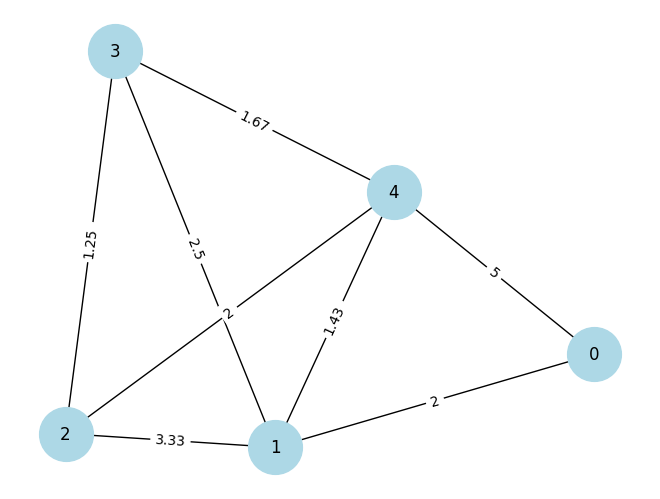

In [12]:
import networkx as nx, matplotlib.pyplot as plt

# 1. Convert your dictionary into a graph in one line
G = nx.Graph([(node, neighbor, {'weight': round(weight, 2)}) for node, edges in graph.items() for neighbor, weight in edges])

# 2. Draw the graph and the weights
pos = nx.spring_layout(G); nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))

# 3. Show it
plt.show()

In [22]:
graph2 = {
    0: [(1,5), (2,1)],
    1: [(0,5), (2,1)],
    2: [(0,1),(1,1)],
}

network_nodes = ["r1", "r2", "r3"]
routing_table = generate_sequence_forwarding_table2(graph2, network_nodes)

import pprint
print("\nGenerated SeQUeNCe Forwarding Rules:")
pprint.pprint(routing_table)

--- Direct route used for r1 -> r2 ---
--- Direct route used for r1 -> r3 ---
--- Direct route used for r2 -> r1 ---
--- Direct route used for r2 -> r3 ---
--- Direct route used for r3 -> r1 ---
--- Direct route used for r3 -> r2 ---

Generated SeQUeNCe Forwarding Rules:
{'r1': [('r2', ['r2'], [1.0]), ('r3', ['r3'], [1.0])],
 'r2': [('r1', ['r1'], [1.0]), ('r3', ['r3'], [1.0])],
 'r3': [('r1', ['r1'], [1.0]), ('r2', ['r2'], [1.0])]}


In [13]:
import networkx as nx, matplotlib.pyplot as plt

# 1. Convert your dictionary into a graph in one line
G = nx.Graph([(node, neighbor, {'weight': round(weight, 2)}) for node, edges in graph2.items() for neighbor, weight in edges])

# 2. Draw the graph and the weights
pos = nx.spring_layout(G); nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))

# 3. Show it
plt.show()

NameError: name 'graph2' is not defined

In [14]:
def generate_full_path_routing_table(adj_list, sequence_nodes):
    """
    Generates a full-path routing table for the custom network simulator.
    
    Output Format:
    routing_table[src][dst] = [("node1", "node2", dist1), ("node2", "node3", dist2)]
    This matches the exact 'path_details' format expected by the swap() function.
    """
    # Create mappings: 'r1' -> 0, 'r2' -> 1, etc.
    str_to_int = {name: idx for idx, name in enumerate(sequence_nodes)}
    int_to_str = {idx: name for idx, name in enumerate(sequence_nodes)}
    
    # Initialize a nested dictionary to store paths: {src: {dst: []}}
    routing_table = {node: {} for node in sequence_nodes}
    
    for src in sequence_nodes:
        for dst in sequence_nodes:
            if src == dst:
                continue
            
            # --- OPTIMIZATION ---
            # Check if we've already computed the reverse path (dst -> src)
            if dst in routing_table and src in routing_table[dst]:
                # print(f"--- Using cached reverse route for {src} -> {dst} ---")
                reverse_path = routing_table[dst][src]
                # Reverse the order of edges and flip the source/destination of each edge
                routing_table[src][dst] = [(v, u, dist) for u, v, dist in reversed(reverse_path)]
                continue
                
            src_idx = str_to_int[src]
            dst_idx = str_to_int[dst]
            
            # 1. Check if the nodes are directly connected and extract distance
            neighbors = adj_list.get(src_idx, [])
            is_directly_connected = False
            distance = 0.0
            
            for neighbor in neighbors:
                # Handle weighted tuples [(node, weight)]
                if isinstance(neighbor, (tuple, list)) and neighbor[0] == dst_idx:
                    is_directly_connected = True
                    distance = neighbor[1]
                    break

            if is_directly_connected:
                print(f"--- Direct route used for {src} -> {dst} ---")
                
                # Format exactly like path_details: list of (src, dst, distance)
                path_details = [(src, dst, distance)]
                routing_table[src][dst] = path_details
                
            else:
                # 2. If not directly connected, run the routing algorithm
                print(f"--- Computing route for {src} -> {dst} via algorithm ---")
                optimal_path_int = algorithm_2(adj_list, src_idx, dst_idx)
                
                if optimal_path_int:
                    path_details = []
                    
                    # Reconstruct the full path with distances for each hop
                    for u, v in optimal_path_int:
                        
                        # Find the distance between intermediate nodes u and v
                        edge_dist = 0.0
                        for edge_neighbor in adj_list.get(u, []):
                            if isinstance(edge_neighbor, (tuple, list)) and edge_neighbor[0] == v:
                                edge_dist = edge_neighbor[1]
                                break
                        
                        u_str = int_to_str[u]
                        v_str = int_to_str[v]
                        
                        # Append the hop to the path_details list
                        path_details.append((u_str, v_str, edge_dist))
                        
                    routing_table[src][dst] = path_details
                else:
                    print(f"[Warning] No path found between {src} and {dst}")
                    routing_table[src][dst] = []
                
    return routing_table

# ==========================================
# How to call it:
# ==========================================

In [15]:
network_nodes = ["r1", "r2", "r3", "r4", "r5"] 

graph = {
    0: [(1, 2), (4, 5)],
    1: [(0, 2), (2, 10/3), (3, 5/2), (4, 10/7)],
    2: [(1, 10/3), (3, 10/8), (4, 2)],
    3: [(1, 5/2), (2, 10/8), (4, 5/3)],
    4: [(0, 5), (1, 10/7), (2, 2), (3, 5/3)]
}

# (Assuming 'algorithm_2' is defined earlier in your script)
routing_table = generate_full_path_routing_table(graph, network_nodes)

# Example Usage with your swap function:
my_path = routing_table["r1"]["r3"]
# swap(node_r1, node_r3, 5, my_path)

--- Direct route used for r1 -> r2 ---
--- Computing route for r1 -> r3 via algorithm ---
  [Quantum] Sifting flow state for 0 -> 2...


KeyboardInterrupt: 

In [17]:
routing_table

#my_path

{'r1': {'r2': [('r1', 'r2', 2)],
  'r3': [('r1', 'r5', 5), ('r5', 'r3', 2)],
  'r4': [('r1', 'r5', 5), ('r5', 'r4', 1.6666666666666667)],
  'r5': [('r1', 'r5', 5)]},
 'r2': {'r1': [('r2', 'r1', 2)],
  'r3': [('r2', 'r3', 3.3333333333333335)],
  'r4': [('r2', 'r4', 2.5)],
  'r5': [('r2', 'r5', 1.4285714285714286)]},
 'r3': {'r1': [('r3', 'r5', 2), ('r5', 'r1', 5)],
  'r2': [('r3', 'r2', 3.3333333333333335)],
  'r4': [('r3', 'r4', 1.25)],
  'r5': [('r3', 'r5', 2)]},
 'r4': {'r1': [('r4', 'r5', 1.6666666666666667), ('r5', 'r1', 5)],
  'r2': [('r4', 'r2', 2.5)],
  'r3': [('r4', 'r3', 1.25)],
  'r5': [('r4', 'r5', 1.6666666666666667)]},
 'r5': {'r1': [('r5', 'r1', 5)],
  'r2': [('r5', 'r2', 1.4285714285714286)],
  'r3': [('r5', 'r3', 2)],
  'r4': [('r5', 'r4', 1.6666666666666667)]}}

In [19]:
my_path2 = routing_table["r1"]["r4"]
my_path2

[('r1', 'r5', 5), ('r5', 'r4', 1.6666666666666667)]

In [16]:
from math import log

network_nodes = ["r1", "r2", "r3", "r4", "r5", "r6"]

graph = {
    0: [(1, -log(0.7727)), (5, -log(0.6018)), (4, -log(0.6541))],
    1: [(0, -log(0.7727)), (2, -log(0.9129)), (5, -log(0.7110))],
    2: [(1, -log(0.9129)), (3, -log(0.6018)), (5, -log(0.7110))],
    3: [(2, -log(0.6018)), (4, -log(0.5094)), (5, -log(0.6541))],
    4: [(0, -log(0.6541)), (3, -log(0.5094)), (5, -log(0.8399))],
    5: [(0, -log(0.6018)), (1, -log(0.7110)), (2, -log(0.7110)), (3, -log(0.6541)), (4, -log(0.8399))]
}

routing_table = generate_full_path_routing_table(graph, network_nodes)
routing_table

--- Direct route used for r1 -> r2 ---
--- Computing route for r1 -> r3 via algorithm ---
  [Quantum] Sifting flow state for 0 -> 2...
  [Classical] Validated e* = (0, 5) (Spike: 2.153 -> 3.171)
  [Split] Dividing at 0-5. Sub-problems: (0->0) and (5->2)
  [Quantum] Sifting flow state for 5 -> 2...
  [Classical] Validated e* = (2, 5) (Spike: 1.420 -> 2.753)
  [Split] Dividing at 5-2. Sub-problems: (5->5) and (2->2)
--- Computing route for r1 -> r4 via algorithm ---
  [Quantum] Sifting flow state for 0 -> 3...
  [Classical] Validated e* = (3, 4) (Spike: 1.660 -> 2.721)
  [Split] Dividing at 4-3. Sub-problems: (0->4) and (3->3)
  [Quantum] Sifting flow state for 0 -> 4...
  [Classical] Validated e* = (0, 4) (Spike: 1.394 -> 3.416)
  [Split] Dividing at 0-4. Sub-problems: (0->0) and (4->4)
--- Direct route used for r1 -> r5 ---
--- Direct route used for r1 -> r6 ---
--- Direct route used for r2 -> r3 ---
--- Computing route for r2 -> r4 via algorithm ---
  [Quantum] Sifting flow state for 

{'r1': {'r2': [('r1', 'r2', 0.2578644040425988)],
  'r3': [('r1', 'r6', 0.5078301147861922), ('r6', 'r3', 0.3410828491788962)],
  'r4': [('r1', 'r5', 0.42449503401496996), ('r5', 'r4', 0.6745217164367805)],
  'r5': [('r1', 'r5', 0.42449503401496996)],
  'r6': [('r1', 'r6', 0.5078301147861922)]},
 'r2': {'r1': [('r2', 'r1', 0.2578644040425988)],
  'r3': [('r2', 'r3', 0.09112893341110193)],
  'r4': [('r2', 'r6', 0.3410828491788962), ('r6', 'r4', 0.42449503401496996)],
  'r5': [('r2', 'r6', 0.3410828491788962),
   ('r6', 'r1', 0.5078301147861922),
   ('r1', 'r5', 0.42449503401496996)],
  'r6': [('r2', 'r6', 0.3410828491788962)]},
 'r3': {'r1': [('r3', 'r6', 0.3410828491788962),
   ('r6', 'r1', 0.5078301147861922)],
  'r2': [('r3', 'r2', 0.09112893341110193)],
  'r4': [('r3', 'r4', 0.5078301147861922)],
  'r5': [('r3', 'r4', 0.5078301147861922), ('r4', 'r5', 0.6745217164367805)],
  'r6': [('r3', 'r6', 0.3410828491788962)]},
 'r4': {'r1': [('r4', 'r5', 0.6745217164367805),
   ('r5', 'r1', 0